# 02 · Planting-date sweep

Compare maize potential grain yield across seven planting dates at Gainesville using the same 1982 weather.

## You will learn

- Build a `Simulation` from a copied FileX.
- Use controls to remove water and nitrogen limitations.
- Run a planting-date sweep and compare grain yield in a table and plot.

In [1]:
LESSON = "02_planting_dates"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

Load date and plotting tools so we can space planting dates and draw results inline.

In [3]:
# Load tools for dates, tables and inline plots.
from datetime import date, timedelta
import matplotlib.pyplot as plt
%matplotlib inline

Choose the copied stock inputs in `runs/` so simulations use fresh inputs on every execution.

In [4]:
# Select the copied FileX, stock weather file and stock soil file.
inputs = {
    "filex": RUNS / "UFGA8201.MZX",
    "weather": RUNS / "UFGA8201.WTH",
    "soil": RUNS / "SOIL.SOL",
    "executable": dssat,
}
print([str(inputs[key].relative_to(HERE)) for key in ("filex", "weather", "soil")])

['runs\\UFGA8201.MZX', 'runs\\UFGA8201.WTH', 'runs\\SOIL.SOL']


🌱 Crop idea

This is stock maize treatment 1 at Gainesville, with cultivar McCurdy 84aa (`IB0035`).
Turning water and nitrogen simulation off represents potential production: weather and crop development still affect yield, while water and nitrogen shortages do not limit growth.

Set water and nitrogen controls to `"N"` so each planting date has the same potential-production conditions.

In [5]:
# Disable water and nitrogen simulation for treatment 1.
experiment = {"treatments": {1: {"controls": {"water": "N", "nitrogen": "N"}}}}
experiment

{'treatments': {1: {'controls': {'water': 'N', 'nitrogen': 'N'}}}}

Build one `Simulation` from the copied FileX so treatment 1 uses these controls and stock inputs.

In [6]:
# Describe the base Simulation without running DSSAT yet.
sim = dl.Simulation(**inputs, treatment=1, management=experiment)

Check the base inputs before running DSSAT; an empty list means no problems were found.

In [7]:
# Check the base Simulation's inputs.
sim.check()

Checks
Weather data: OK
Soil data: OK
FileX: OK
Management data: OK
  Treatment 1: OK
    planting: OK (omitted; keeps the FileX Level)
    irrigation: OK (omitted; keeps the FileX Level)
    fertilizer: OK (omitted; keeps the FileX Level)
    residues: OK (omitted; keeps the FileX Level)
    tillage: OK (omitted; keeps the FileX Level)
    harvest: OK (omitted; keeps the FileX Level)
    cultivar: OK (omitted; keeps the FileX Level)
    initial_conditions: OK (omitted; keeps the FileX Level)
    soil_analysis: OK (omitted; keeps the FileX Level)
    environment: OK (omitted; keeps the FileX Level)
    controls: OK
Crop-specific fields are checked by DSSAT at run time.


[]

Run the base Simulation so we have potential yield at the stock planting date.

In [8]:
# Run treatment 1 with water and nitrogen simulation off.
base_result = sim.run()
print(base_result.run_dir.relative_to(HERE))

runs\dssat_sim_2026-10-06_195731\dssat_run_2026-10-06_195731


Read the base Summary to see planting date (`PDAT`) and grain yield (`HWAM`, kg/ha).

In [9]:
# Show the base planting date and potential grain yield.
dl.to_dataframe(dl.read_summary(base_result.run_dir))[["TRNO", "PDAT", "HWAM"]]

,TRNO,PDAT,HWAM
0,1,1982-02-26,11859


🐍 Python idea

A dictionary pairs a name with a value, such as `"water": "N"`.
`**inputs` passes the dictionary entries as named arguments to a function.

Keep the stock planting details fixed so the sweep changes only planting date.

In [10]:
# Keep stock plant population, row spacing and planting depth.
planting = {
    "method": "S",
    "distribution": "R",
    "population": 7.2,
    "emergence_population": 7.2,
    "row_spacing": 61,
    "row_direction": 0,
    "depth": 7,
    "sprout_length": 0,
}
planting

{'method': 'S',
 'distribution': 'R',
 'population': 7.2,
 'emergence_population': 7.2,
 'row_spacing': 61,
 'row_direction': 0,
 'depth': 7,
 'sprout_length': 0}

Population is in plants/m², row spacing and planting depth are in cm, and `S` and `R` mean seed and rows.

Start at 26 February 1982, the stock FileX planting date `82057`, to anchor the comparison.

In [11]:
# Set the first planting date from the stock FileX.
first_date = date(1982, 2, 26)
first_date.isoformat()

'1982-02-26'

Choose 14-day spacing to test planting dates two weeks apart.

In [12]:
# Set the number of days between planting dates.
spacing_days = 14
spacing_days

14

### Dates and results

Make seven calendar dates so every scenario has a clear planting-date label.

In [13]:
# Make seven planting dates at the chosen spacing.
dates = [(first_date + timedelta(days=spacing_days * i)).isoformat() for i in range(7)]
dates

['1982-02-26',
 '1982-03-12',
 '1982-03-26',
 '1982-04-09',
 '1982-04-23',
 '1982-05-07',
 '1982-05-21']

🐍 Python idea

`range(7)` counts from 0 through 6, and `timedelta(days=...)` moves a date by that many days.
The expression inside the square brackets makes one list entry for each count.

Build a planting factor that supplies the complete planting section for each date.

In [14]:
# Give each labelled date the same planting details.
factors = {"planting": {day: dict(planting, date=day) for day in dates}}
list(factors["planting"])

['1982-02-26',
 '1982-03-12',
 '1982-03-26',
 '1982-04-09',
 '1982-04-23',
 '1982-05-07',
 '1982-05-21']

`dict(planting, date=day)` copies the fixed details and adds a date.
A sweep replaces the whole planting section, so every date needs those details.

Run the sweep so DSSAT calculates a base row followed by seven planting-date scenarios.

In [15]:
# Run the base and all seven planting-date scenarios.
rows = dl.run_sweep(**inputs, treatments=[1], management=experiment, factors=factors)
print(f"Summary rows: {len(rows)} (1 base + 7 planting dates)")

Summary rows: 8 (1 base + 7 planting dates)


Show all eight Summary rows to check the base and the seven dated scenarios together.

In [16]:
# Show actual planting dates and grain yield without run-directory paths.
results = dl.to_dataframe(rows)
results[["scenario", "planting", "PDAT", "HWAM"]]

,scenario,planting,PDAT,HWAM
0,base,NaN,1982-02-26,11859
1,1982-02-26,1982-02-26,1982-02-26,11859
2,1982-03-12,1982-03-12,1982-03-12,9254
3,1982-03-26,1982-03-26,1982-03-26,12321
4,1982-04-09,1982-04-09,1982-04-09,9958
5,1982-04-23,1982-04-23,1982-04-23,11640
6,1982-05-07,1982-05-07,1982-05-07,10217
7,1982-05-21,1982-05-21,1982-05-21,7775


The `base` row keeps the stock planting date and the potential-production controls.
Its factor label is empty because it is a reference run, and `PDAT` is the actual planting date, read by dssatlab as a calendar date.

Keep only the seven labelled scenarios so the graph contains each planting date once.

In [17]:
# Select the seven planting-date rows for comparison.
comparison = results.loc[results["scenario"] != "base", ["planting", "HWAM"]].copy()
comparison

,planting,HWAM
1,1982-02-26,11859
2,1982-03-12,9254
3,1982-03-26,12321
4,1982-04-09,9958
5,1982-04-23,11640
6,1982-05-07,10217
7,1982-05-21,7775


Plot potential grain yield against planting date to see how the planting window changes the result.

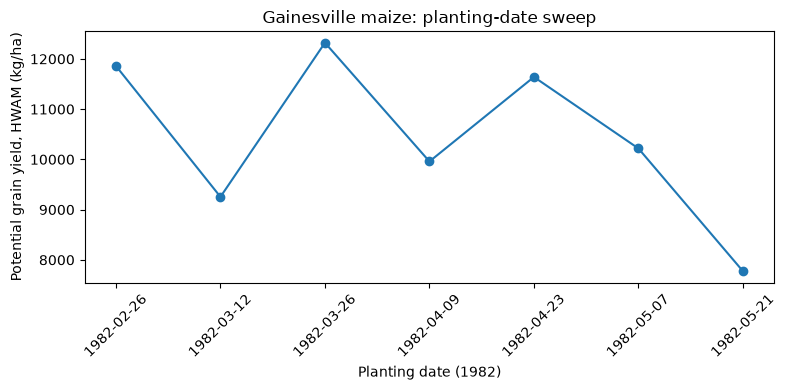

In [18]:
# Plot the seven potential yields inline.
ax = comparison.plot(x="planting", y="HWAM", marker="o", legend=False, figsize=(8, 4))
ax.set(xlabel="Planting date (1982)", ylabel="Potential grain yield, HWAM (kg/ha)", title="Gainesville maize: planting-date sweep")
ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()
plt.show()

🌱 Crop idea

Later planting exposes the crop to a different sequence of temperature and solar radiation.
Warmer conditions can speed development and change the time available to intercept light and fill grain, so potential yield can change even without water or nitrogen limitations.
This one season is a comparison of these dates, not a recommendation for all years.

## Your turn

Change the spacing to 21 days and compare the new seven-date table and plot.

Hint: run the cell below, then rerun the cells under **Dates and results** through the plot.

In [19]:
# Set 21-day spacing before rerunning Dates and results.
spacing_days = 21
spacing_days

21

## Recap

- A `Simulation` combines one FileX treatment with inputs and controls.
- Water and nitrogen controls set to `"N"` remove those limits for this potential-production comparison.
- A sweep returns a base row plus labelled scenarios; `HWAM` compares grain yield in kg/ha.

Next: [Comparing cultivars and maturity groups](../03_cultivars/lesson.ipynb).